<a href="https://colab.research.google.com/github/Bhumiii27/ML-Labs/blob/main/Lab4_Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#POLYNOMIAL REGRESSIONNN

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [ ]:
data=load_diabetes()

In [ ]:
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [ ]:
x=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target

In [ ]:
x

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [ ]:
features=['bmi','bp','s5']
X=x[features]

#Reducing parameters for now, do all in hw

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
#scaler=StandardScaler()
#x_train=scaler.fit_transform(X_train)
#X_test=scaler.transform(X_test)

In [ ]:
def costfunction(y_actual,y_predicted):
  m=len(y_actual)
  #summ=summation
  summ=np.sum((y_actual-y_predicted)**2)
  return (summ/(2*m))

In [ ]:
# Polynomial Regression

degree = range(1, 7)
cost_values = []

for deg in degree:

    poly = PolynomialFeatures(degree=deg, include_bias=False)

    x_train_poly = poly.fit_transform(X_train)
    x_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(x_train_poly, Y_train)

    y_pred = model.predict(x_test_poly)

    cost = costfunction(Y_test, y_pred)
    cost_values.append(cost)

In [ ]:
for deg, cost in zip(degree, cost_values):
    print("Degree:", deg, "Cost:", cost)

Degree: 1 Cost: 1470.852613128517
Degree: 2 Cost: 1409.3002275363228
Degree: 3 Cost: 1569.055398182801
Degree: 4 Cost: 1787.3096445030017
Degree: 5 Cost: 1893.2354264905773
Degree: 6 Cost: 2995.0288460118304


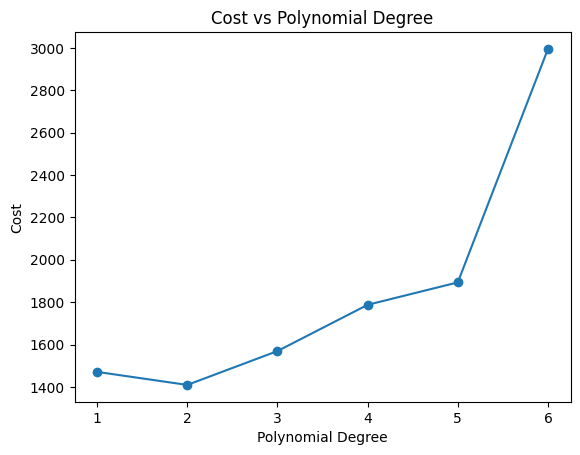

In [ ]:
#Plot degree vs cost
plt.plot(degree, cost_values, marker='o')

plt.xlabel("Polynomial Degree")
plt.ylabel("Cost")
plt.title("Cost vs Polynomial Degree")

plt.show()

In [ ]:
# Best Polynomial Regression Model

poly = PolynomialFeatures(degree=3, include_bias=False)

x_train_poly = poly.fit_transform(X_train)
x_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(x_train_poly, Y_train)

y_pred = model.predict(x_test_poly)

In [ ]:
best_degree = degree[np.argmin(cost_values)]

print("Best Degree:", best_degree)
print("Minimum Cost:", min(cost_values))

Best Degree: 2
Minimum Cost: 1409.3002275363228


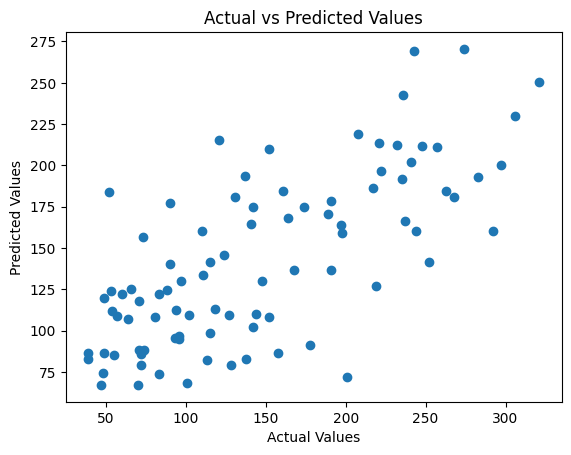

In [ ]:
# Train the best polynomial model
poly = PolynomialFeatures(degree=best_degree, include_bias=False)

x_train_poly = poly.fit_transform(X_train)
x_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(x_train_poly, Y_train)

y_pred = model.predict(x_test_poly)

# Actual vs Predicted
plt.scatter(Y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()